<a href="https://colab.research.google.com/github/amathie5/PPS-Project-/blob/main/pps_project_final_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1
### **I. Aggregate Production Planning**


# 1. Data and Assumptions

This section presents the key parameters and data used to build the aggregate production planning models for Aurelius SA.

The planning horizon is 12 months, from January to December. The company faces fluctuating demand and must decide on workforce levels, production, inventory, overtime, and subcontracting to minimize total costs.

We assume:
- Constant production rate per worker
- Monthly planning periods
- Deterministic demand
- Costs are linear
- No backorders allowed (inventory must remain non-negative)

In [2]:
pip install pulp numpy pandas matplotlib


In [3]:
import pandas as pd
import numpy as np

In [4]:
# Planning horizon
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
T = range(12)

# Demand
demand = [900, 950, 1200, 1050, 1100, 1300,
          1250, 1100, 1300, 1450, 1500, 1700]

# Initial conditions
initial_workers = 90
initial_inventory = 900
target_inventory = 1000

# Production
prod_rate = 10  # watches per worker per month

# Costs
wage = 7000
hire_cost = 50000
fire_cost = 25000
holding_cost = 1000

# Overtime
overtime_multiplier = 0.2
overtime_cost = 7000
overtime_allowed = [0,0,1,0,1,0,0,0,1,0,0,1]

# Subcontracting
sub_limit = 300
sub_cost = 15000
sub_allowed = [0,0,0,0,0,1,1,0,0,1,0,1]

# 2. Problem Framing

The goal of this aggregate production planning problem is to determine a feasible and cost-effective monthly production plan for Aurelius SA over a 12-month horizon.

The company must satisfy monthly demand while deciding:
- workforce levels,
- hiring and firing decisions,
- regular production,
- overtime usage in eligible months,
- subcontracting in eligible months,
- inventory levels.

The objective is to minimize the total cost of the production plan while ensuring that all customer demand is met and that the company reaches its target ending inventory level.

The total cost includes:
- regular workforce wages,
- hiring costs,
- layoff costs,
- inventory holding costs,
- overtime costs,
- subcontracting costs.

We assume that demand is deterministic, no backorders are allowed, and all decisions are made on a monthly basis.

## 2.1 Decision Variables

For each month \(t\), we define the following decision variables:

- \(W_t\): number of workers employed
- \(H_t\): number of workers hired
- \(F_t\): number of workers laid off
- \(P_t\): regular production quantity
- \(I_t\): inventory level at the end of the month
- \(OT_t\): overtime production quantity
- \(S_t\): subcontracted quantity

## 2.2 Objective Function

The objective is to minimize the total cost over the planning horizon:

\[
\min \sum_{t=1}^{12} \left(
7000 W_t
+ 50000 H_t
+ 25000 F_t
+ 1000 I_t
+ 14000 OT_t
+ 15000 S_t
\right)
\]

where:
- regular wages are paid for each worker employed,
- hiring and layoff costs apply to workforce changes,
- inventory holding costs are charged on ending inventory,
- overtime production is more expensive than regular production,
- subcontracting is also costly and limited to specific months.

## 2.3 Constraints

### Workforce balance

The workforce evolves over time according to hiring and firing decisions:

\[
W_t = W_{t-1} + H_t - F_t \qquad \forall t = 2, \dots, 12
\]

For the first month:

\[
W_1 = 90 + H_1 - F_1
\]

## 2.4 Managerial interpretation

This model balances workforce stability, inventory accumulation, overtime flexibility, and subcontracting opportunities.

Hiring and firing allow the firm to adapt capacity over time, but they are costly. Inventory can be used to anticipate demand peaks, but holding inventory is expensive. Overtime provides temporary flexibility in selected months, while subcontracting offers an external capacity option at a high per-unit cost.

The optimization model determines the least-cost combination of these levers while satisfying all demand and operational constraints.

In [5]:
# Model sets and parameters are already defined in Section 1
n_months = len(months)

print("Planning horizon:", n_months, "months")
print("Total annual demand:", sum(demand))
print("Initial workforce:", initial_workers)
print("Initial inventory:", initial_inventory)
print("Target ending inventory:", target_inventory)

Planning horizon: 12 months
Total annual demand: 14800
Initial workforce: 90
Initial inventory: 900
Target ending inventory: 1000


# 3. Benchmark Strategy 1: Level Strategy

The level strategy keeps the workforce constant throughout the planning horizon. As a result, regular production remains constant every month.

Demand fluctuations are absorbed through inventory accumulation and depletion. This strategy is attractive when management prefers workforce stability and wants to avoid frequent hiring and firing decisions.

However, the downside is that inventory levels can become high, which may generate significant holding costs.

In [6]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Total production required over the year
total_demand = sum(demand)
required_production = total_demand + target_inventory - initial_inventory

# Constant monthly production
level_monthly_production = required_production / 12

# Constant workforce needed
level_workers = math.ceil(level_monthly_production / prod_rate)

# Actual production with rounded workforce
level_actual_production = level_workers * prod_rate

print("Total demand:", total_demand)
print("Required annual production:", required_production)
print("Target constant monthly production:", level_monthly_production)
print("Constant workforce (rounded up):", level_workers)
print("Actual monthly production:", level_actual_production)

Total demand: 14800
Required annual production: 14900
Target constant monthly production: 1241.6666666666667
Constant workforce (rounded up): 125
Actual monthly production: 1250


In [7]:
#plan par mois
level_inventory = []
level_production = []
level_workforce = []
level_hiring = []
level_firing = []

current_inventory = initial_inventory
previous_workers = initial_workers

for t in T:
    workers_t = level_workers
    production_t = level_actual_production

    hire_t = max(0, workers_t - previous_workers)
    fire_t = max(0, previous_workers - workers_t)

    current_inventory = current_inventory + production_t - demand[t]

    level_workforce.append(workers_t)
    level_production.append(production_t)
    level_hiring.append(hire_t)
    level_firing.append(fire_t)
    level_inventory.append(current_inventory)

    previous_workers = workers_t

In [8]:
level_df = pd.DataFrame({
    "Month": months,
    "Demand": demand,
    "Workforce": level_workforce,
    "Hiring": level_hiring,
    "Firing": level_firing,
    "Production": level_production,
    "Ending Inventory": level_inventory
})

level_df

,Month,Demand,Workforce,Hiring,Firing,Production,Ending Inventory
0,Jan,900,125,35,0,1250,1250
1,Feb,950,125,0,0,1250,1550
2,Mar,1200,125,0,0,1250,1600
3,Apr,1050,125,0,0,1250,1800
4,May,1100,125,0,0,1250,1950
5,Jun,1300,125,0,0,1250,1900
6,Jul,1250,125,0,0,1250,1900
7,Aug,1100,125,0,0,1250,2050
8,Sep,1300,125,0,0,1250,2000
9,Oct,1450,125,0,0,1250,1800


In [9]:
#fasibity
print("Minimum inventory:", min(level_inventory))
print("Ending inventory:", level_inventory[-1])

Minimum inventory: 1100
Ending inventory: 1100


In [10]:
#cost
level_wage_cost = sum(w * wage for w in level_workforce)
level_hiring_cost = sum(h * hire_cost for h in level_hiring)
level_firing_cost = sum(f * fire_cost for f in level_firing)
level_holding_cost = sum(i * holding_cost for i in level_inventory)

level_total_cost = (
    level_wage_cost
    + level_hiring_cost
    + level_firing_cost
    + level_holding_cost
)

level_cost_summary = pd.DataFrame({
    "Cost Component": ["Wages", "Hiring", "Firing", "Holding", "Total"],
    "Value": [level_wage_cost, level_hiring_cost, level_firing_cost, level_holding_cost, level_total_cost]
})

level_cost_summary

,Cost Component,Value
0,Wages,10500000
1,Hiring,1750000
2,Firing,0
3,Holding,20450000
4,Total,32700000


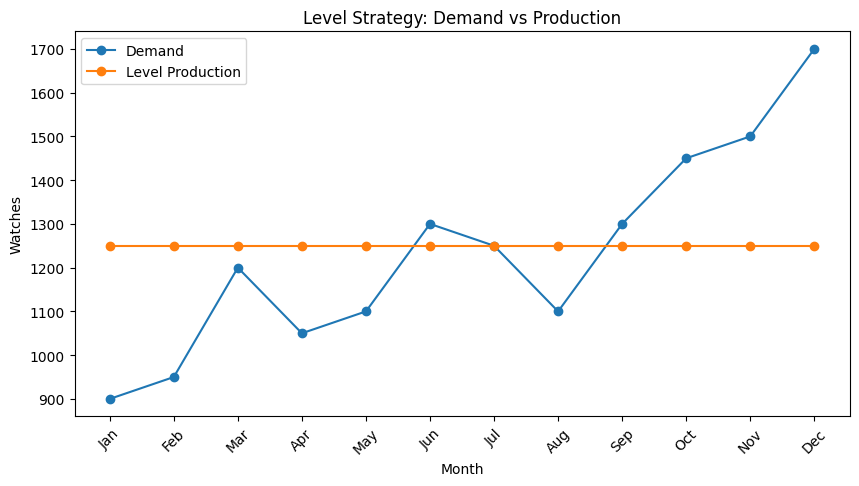

In [11]:
plt.figure(figsize=(10,5))
plt.plot(months, demand, marker='o', label="Demand")
plt.plot(months, level_production, marker='o', label="Level Production")
plt.title("Level Strategy: Demand vs Production")
plt.xlabel("Month")
plt.ylabel("Watches")
plt.legend()
plt.xticks(rotation=45)
plt.show()

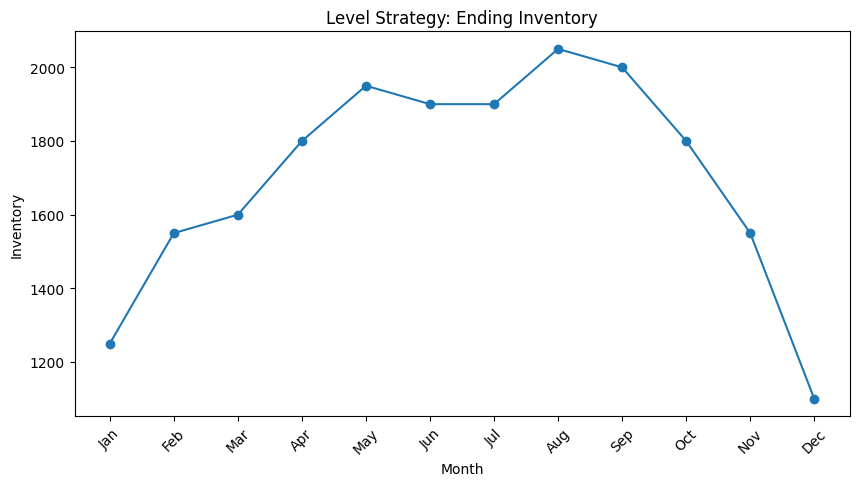

In [12]:
plt.figure(figsize=(10,5))
plt.plot(months, level_inventory, marker='o')
plt.title("Level Strategy: Ending Inventory")
plt.xlabel("Month")
plt.ylabel("Inventory")
plt.xticks(rotation=45)
plt.show()

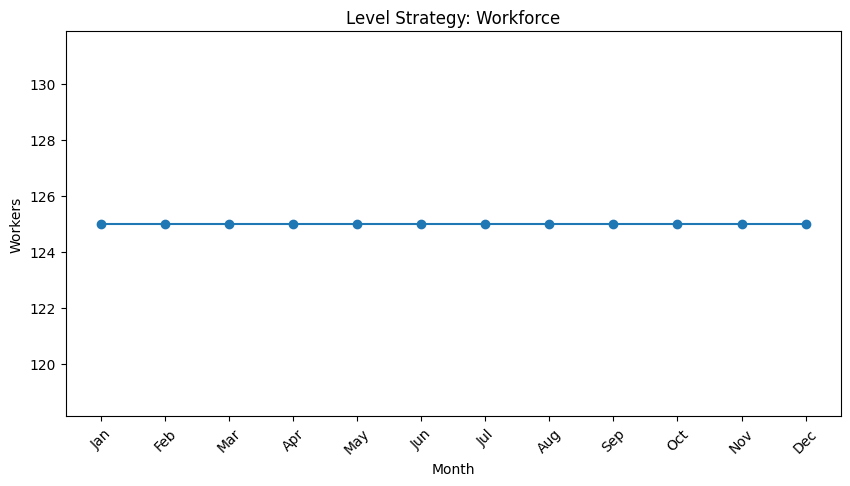

In [13]:
plt.figure(figsize=(10,5))
plt.plot(months, level_workforce, marker='o')
plt.title("Level Strategy: Workforce")
plt.xlabel("Month")
plt.ylabel("Workers")
plt.xticks(rotation=45)
plt.show()

In [14]:
## Parameters
horizon = 12    #in months
w_i = 90        # Initial number of workers
p = 10          #Production rate per worker per month
inv_i = 900     # Initial inventory
inv_t = 1000    # Final inventory target by end of December
hold = 1000     # Inventory holding cost per watch per month (security/insurance)
wage_r = 7000   # Regular wage/worker/month
hiring = 50000  # Hiring cost per worker
layoff = 25000  # layoff cost per worker
max_overtime = 0.2  # overtime allowance......
overtime_cost = 14000 # 2x wage_r
subcontracting_cost = 15000 # CHF per watch
max_contracting = 300 # watches per month
overtime_months = [3,5,9,12] # march, may, sept, dec
subcontracting_months = [6,7,10,12] # june, july, oct, dec
demand = [900,950,1200,1050,1100,1300,1250,1100,1300,1450,1500,1700]

## 3.1 Interpretation of the Level Strategy

The level strategy ensures workforce stability by keeping the number of workers constant over the entire planning horizon. This avoids repeated hiring and firing, which can be desirable in a luxury manufacturing environment where skills are valuable and training is expensive.

However, because demand fluctuates significantly over the year, this strategy relies heavily on inventory to absorb variations. As a result, inventory levels can become high, leading to substantial holding costs.

This benchmark therefore illustrates the trade-off between workforce stability and inventory cost.

# 4. Benchmark Strategy 2: Chase Strategy

The chase strategy adjusts production to match demand as closely as possible in each month. As a result, inventory is kept to a minimum, and demand is satisfied mainly through workforce adjustments.

This strategy reduces inventory holding costs, but it may require frequent hiring and firing, which can be expensive and operationally disruptive.

It provides a useful benchmark to compare against the level strategy and the optimized MILP models.

In [15]:
import math
chase_production = demand.copy()
chase_workforce = [math.ceil(p / prod_rate) for p in chase_production]

In [16]:
#Inventory Simulation
chase_inventory = []
chase_hiring = []
chase_firing = []

current_inventory = initial_inventory
previous_workers = initial_workers

for t in T:
    production_t = chase_production[t]
    workers_t = chase_workforce[t]

    hire_t = max(0, workers_t - previous_workers)
    fire_t = max(0, previous_workers - workers_t)

    current_inventory = current_inventory + production_t - demand[t]

    chase_inventory.append(current_inventory)
    chase_hiring.append(hire_t)
    chase_firing.append(fire_t)

    previous_workers = workers_t

In [17]:
# December correction for the target inventory
extra_needed_december = target_inventory - chase_inventory[-1]
chase_production[-1] += extra_needed_december
chase_workforce[-1] = math.ceil(chase_production[-1] / prod_rate)

chase_inventory = []
chase_hiring = []
chase_firing = []

current_inventory = initial_inventory
previous_workers = initial_workers

for t in T:
    production_t = chase_production[t]
    workers_t = chase_workforce[t]

    hire_t = max(0, workers_t - previous_workers)
    fire_t = max(0, previous_workers - workers_t)

    current_inventory = current_inventory + production_t - demand[t]

    chase_inventory.append(current_inventory)
    chase_hiring.append(hire_t)
    chase_firing.append(fire_t)

    previous_workers = workers_t

In [18]:
chase_df = pd.DataFrame({
    "Month": months,
    "Demand": demand,
    "Production": chase_production,
    "Workforce": chase_workforce,
    "Hiring": chase_hiring,
    "Firing": chase_firing,
    "Ending Inventory": chase_inventory
})

chase_df

,Month,Demand,Production,Workforce,Hiring,Firing,Ending Inventory
0,Jan,900,900,90,0,0,900
1,Feb,950,950,95,5,0,900
2,Mar,1200,1200,120,25,0,900
3,Apr,1050,1050,105,0,15,900
4,May,1100,1100,110,5,0,900
5,Jun,1300,1300,130,20,0,900
6,Jul,1250,1250,125,0,5,900
7,Aug,1100,1100,110,0,15,900
8,Sep,1300,1300,130,20,0,900
9,Oct,1450,1450,145,15,0,900


In [19]:
#verification
print("Minimum inventory:", min(chase_inventory))
print("Ending inventory:", chase_inventory[-1])

Minimum inventory: 900
Ending inventory: 1000


In [20]:
# Cost
chase_wage_cost = sum(w * wage for w in chase_workforce)
chase_hiring_cost = sum(h * hire_cost for h in chase_hiring)
chase_firing_cost = sum(f * fire_cost for f in chase_firing)
chase_holding_cost = sum(i * holding_cost for i in chase_inventory)

chase_total_cost = (
    chase_wage_cost
    + chase_hiring_cost
    + chase_firing_cost
    + chase_holding_cost
)

chase_cost_summary = pd.DataFrame({
    "Cost Component": ["Wages", "Hiring", "Firing", "Holding", "Total"],
    "Value": [chase_wage_cost, chase_hiring_cost, chase_firing_cost, chase_holding_cost, chase_total_cost]
})

chase_cost_summary

,Cost Component,Value
0,Wages,10430000
1,Hiring,6250000
2,Firing,875000
3,Holding,10900000
4,Total,28455000


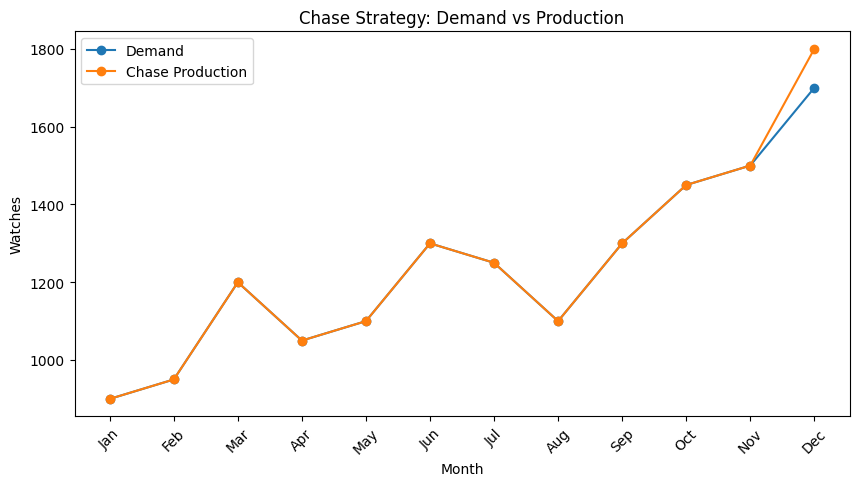

In [21]:
plt.figure(figsize=(10,5))
plt.plot(months, demand, marker='o', label="Demand")
plt.plot(months, chase_production, marker='o', label="Chase Production")
plt.title("Chase Strategy: Demand vs Production")
plt.xlabel("Month")
plt.ylabel("Watches")
plt.legend()
plt.xticks(rotation=45)
plt.show()

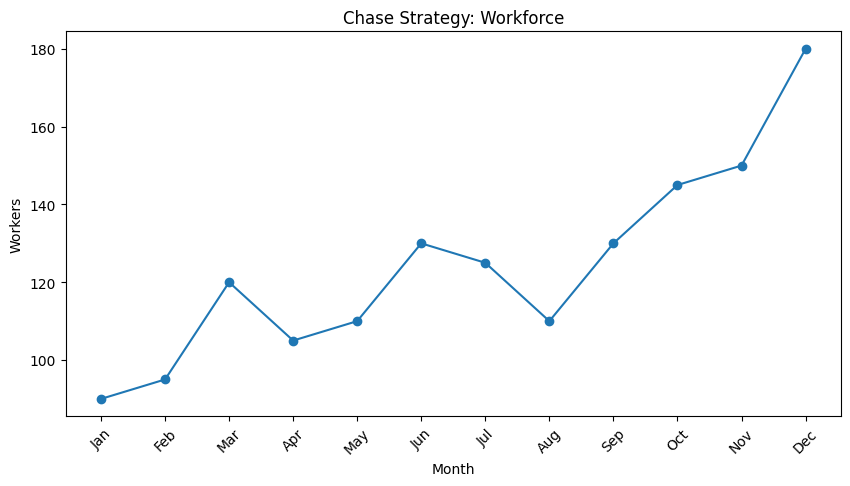

In [22]:
plt.figure(figsize=(10,5))
plt.plot(months, chase_workforce, marker='o')
plt.title("Chase Strategy: Workforce")
plt.xlabel("Month")
plt.ylabel("Workers")
plt.xticks(rotation=45)
plt.show()

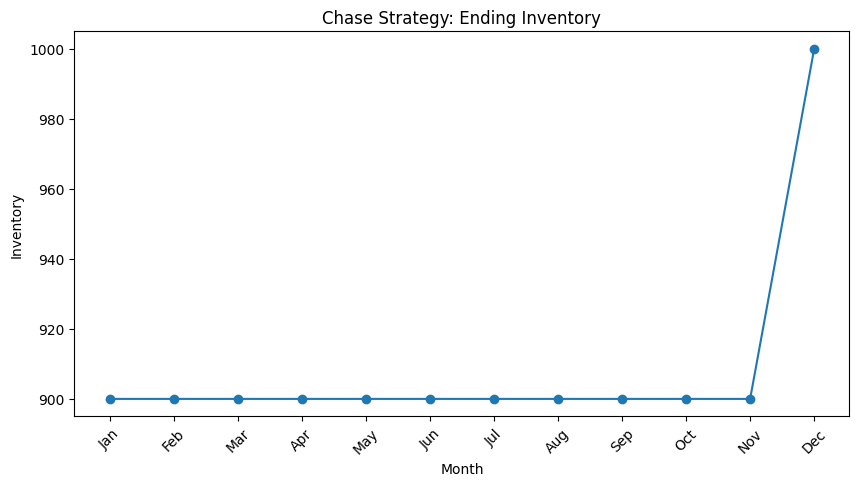

In [23]:
plt.figure(figsize=(10,5))
plt.plot(months, chase_inventory, marker='o')
plt.title("Chase Strategy: Ending Inventory")
plt.xlabel("Month")
plt.ylabel("Inventory")
plt.xticks(rotation=45)
plt.show()

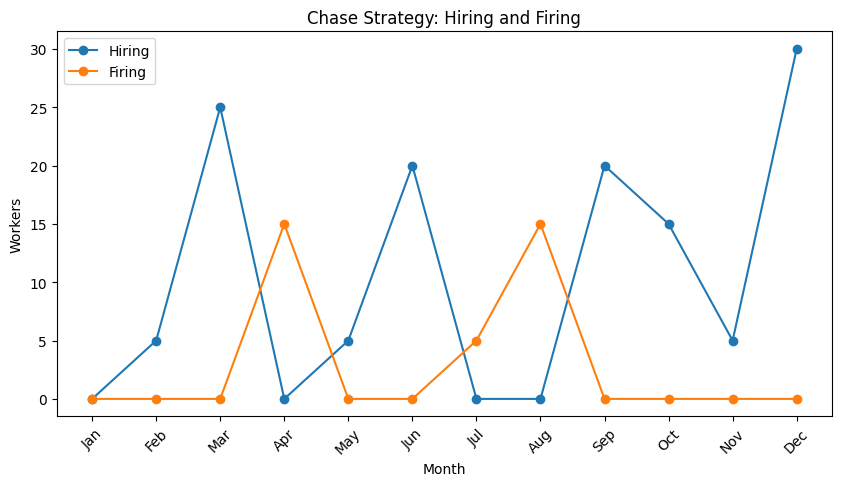

In [24]:
plt.figure(figsize=(10,5))
plt.plot(months, chase_hiring, marker='o', label="Hiring")
plt.plot(months, chase_firing, marker='o', label="Firing")
plt.title("Chase Strategy: Hiring and Firing")
plt.xlabel("Month")
plt.ylabel("Workers")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 4.1 Interpretation of the Chase Strategy

The chase strategy keeps inventory low by adjusting production to monthly demand. This reduces the need to carry large inventories and therefore limits holding costs.

However, this comes at the expense of workforce stability. Because demand fluctuates over the year, the company must frequently hire and lay off workers, which is particularly costly in a luxury manufacturing environment where training is expensive and craftsmanship is valuable.

This benchmark illustrates the opposite trade-off from the level strategy: lower inventory costs, but higher workforce adjustment costs.

# 5. Comparison of Benchmark Strategies

This section compares the two classical aggregate planning benchmarks: the level strategy and the chase strategy.

The comparison focuses on the main operational trade-offs:
- total cost,
- workforce stability,
- inventory levels,
- hiring and firing intensity.

These benchmark strategies provide useful reference points before introducing the optimized MILP models.

In [25]:
comparison_benchmark = pd.DataFrame({
    "Strategy": ["Level", "Chase"],
    "Total Cost": [level_total_cost, chase_total_cost],
    "Total Hiring": [sum(level_hiring), sum(chase_hiring)],
    "Total Firing": [sum(level_firing), sum(chase_firing)],
    "Average Workforce": [np.mean(level_workforce), np.mean(chase_workforce)],
    "Max Inventory": [max(level_inventory), max(chase_inventory)],
    "Ending Inventory": [level_inventory[-1], chase_inventory[-1]]
})

comparison_benchmark

,Strategy,Total Cost,Total Hiring,Total Firing,Average Workforce,Max Inventory,Ending Inventory
0,Level,32700000,35,0,125.000000,2050,1100
1,Chase,28455000,125,35,124.166667,1000,1000


In [26]:
benchmark_costs = pd.DataFrame({
    "Cost Component": ["Wages", "Hiring", "Firing", "Holding", "Total"],
    "Level": [
        level_wage_cost,
        level_hiring_cost,
        level_firing_cost,
        level_holding_cost,
        level_total_cost
    ],
    "Chase": [
        chase_wage_cost,
        chase_hiring_cost,
        chase_firing_cost,
        chase_holding_cost,
        chase_total_cost
    ]
})

benchmark_costs

,Cost Component,Level,Chase
0,Wages,10500000,10430000
1,Hiring,1750000,6250000
2,Firing,0,875000
3,Holding,20450000,10900000
4,Total,32700000,28455000


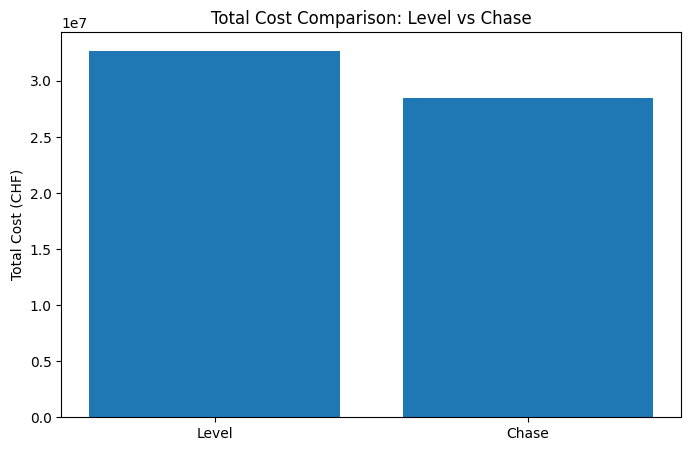

In [27]:
plt.figure(figsize=(8,5))
plt.bar(comparison_benchmark["Strategy"], comparison_benchmark["Total Cost"])
plt.title("Total Cost Comparison: Level vs Chase")
plt.ylabel("Total Cost (CHF)")
plt.show()

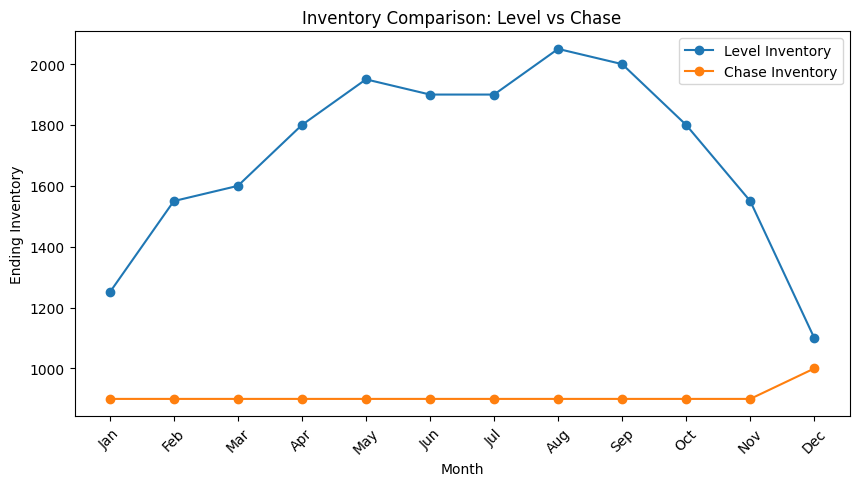

In [28]:
plt.figure(figsize=(10,5))
plt.plot(months, level_inventory, marker='o', label="Level Inventory")
plt.plot(months, chase_inventory, marker='o', label="Chase Inventory")
plt.title("Inventory Comparison: Level vs Chase")
plt.xlabel("Month")
plt.ylabel("Ending Inventory")
plt.legend()
plt.xticks(rotation=45)
plt.show()

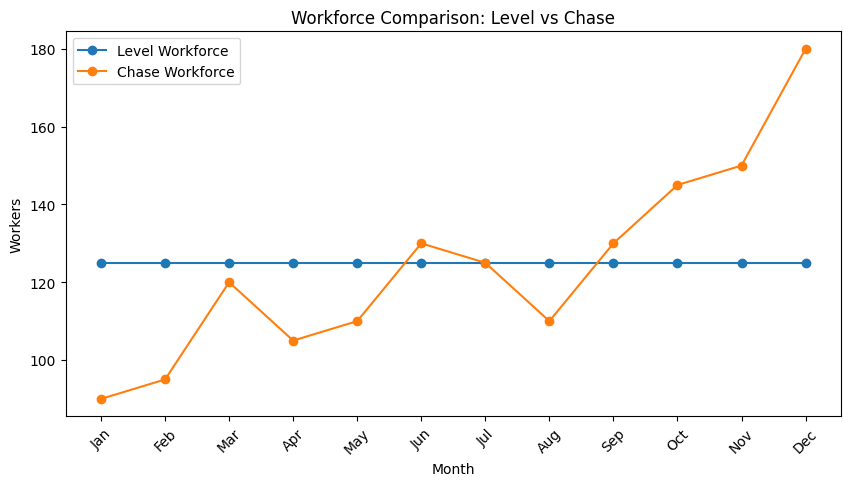

In [29]:
plt.figure(figsize=(10,5))
plt.plot(months, level_workforce, marker='o', label="Level Workforce")
plt.plot(months, chase_workforce, marker='o', label="Chase Workforce")
plt.title("Workforce Comparison: Level vs Chase")
plt.xlabel("Month")
plt.ylabel("Workers")
plt.legend()
plt.xticks(rotation=45)
plt.show()

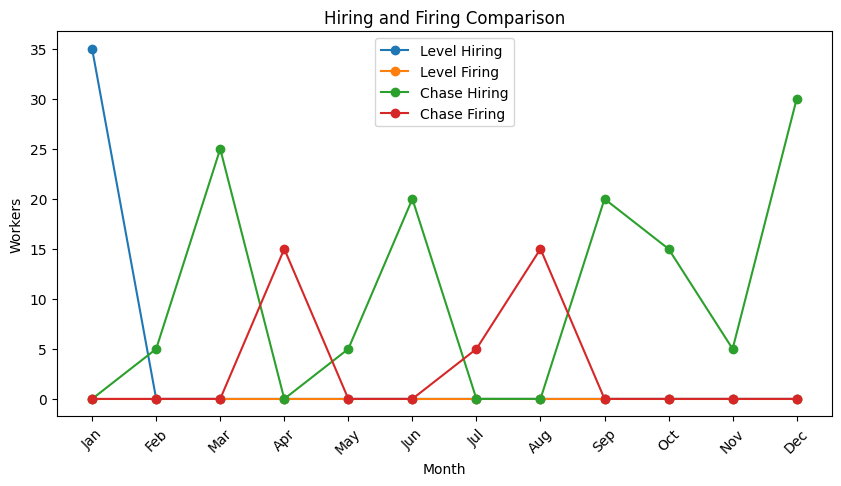

In [30]:
plt.figure(figsize=(10,5))
plt.plot(months, level_hiring, marker='o', label="Level Hiring")
plt.plot(months, level_firing, marker='o', label="Level Firing")
plt.plot(months, chase_hiring, marker='o', label="Chase Hiring")
plt.plot(months, chase_firing, marker='o', label="Chase Firing")
plt.title("Hiring and Firing Comparison")
plt.xlabel("Month")
plt.ylabel("Workers")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 5.1 Interpretation of Benchmark Comparison

The level and chase strategies illustrate two opposite approaches to aggregate planning.

The level strategy prioritizes workforce stability by maintaining a constant number of workers throughout the year. This avoids repeated hiring and firing but leads to higher inventory levels, which increases holding costs.

By contrast, the chase strategy adjusts workforce and production more closely to monthly demand. This reduces inventory levels and associated holding costs, but it creates significant workforce instability and generates higher hiring and firing costs.

These two benchmarks clearly highlight the main aggregate planning trade-off:
- the level strategy is more stable but more inventory-intensive,
- the chase strategy is more demand-responsive but more disruptive in terms of workforce management.

For Aurelius SA, a luxury watch manufacturer with expensive training and highly skilled labor, neither benchmark is likely to be fully satisfactory on its own. This motivates the use of an optimization model that can balance workforce, inventory, overtime, and subcontracting more efficiently.

# 6. MILP Formulation and Coding

The benchmark strategies highlight the trade-off between workforce stability and inventory cost. To go beyond these extreme approaches, we now formulate an aggregate production planning model as a mixed-integer linear program.

The model determines the optimal monthly production plan by jointly deciding:
- workforce levels,
- hiring and firing decisions,
- regular production,
- overtime usage,
- subcontracting,
- inventory levels.

The objective is to minimize total cost while satisfying demand and operational constraints.

## 6.1 Model implementation note

To keep the notebook structured and reusable, the aggregate planning model is implemented as a generic function. This allows us to solve several versions of the problem by activating or deactivating overtime and subcontracting options.

This design is especially useful for:
- comparing different planning configurations,
- conducting sensitivity analysis efficiently,
- keeping the code concise and readable.

# 7. MILP Models Comparison

We now solve four versions of the aggregate production planning model with increasing levels of flexibility.

The goal is to understand how different operational levers (overtime and subcontracting) impact total cost and production decisions.

The four models are:
- Model 1: No overtime, no subcontracting
- Model 2: Overtime only
- Model 3: Subcontracting only
- Model 4: Overtime and subcontracting

These models allow us to evaluate the value of flexibility in production planning.

## 7.1 Model 1: Base model (no overtime, no subcontracting)

This model includes only:
- workforce decisions,
- hiring and firing,
- regular production,
- inventory.

No overtime or subcontracting is allowed.

In [31]:
# Model Base
#---------------------------


from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpInteger, LpContinuous, LpStatus, value
import pandas as pd
import numpy as np
from pulp import *

def solve_model_1(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost
):

    months = len(demand)
    model = LpProblem("Model_1_Base", LpMinimize)

    # Variables
    W = LpVariable.dicts("Workers", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("Hire", range(months), lowBound=0, cat=LpInteger)
    F = LpVariable.dicts("Fire", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("Production", range(months), lowBound=0)
    I = LpVariable.dicts("Inventory", range(months), lowBound=0)

    # Objective
    model += lpSum(
        W[t] * wage +
        H[t] * hire_cost +
        F[t] * fire_cost +
        I[t] * holding_cost
        for t in range(months)
    )

    for t in range(months):

        # Capacity
        model += P[t] <= W[t] * prod_rate

        if t == 0:
            model += W[t] == initial_workers + H[t] - F[t]
            model += I[t] == initial_inventory + P[t] - demand[t]
        else:
            model += W[t] == W[t-1] + H[t] - F[t]
            model += I[t] == I[t-1] + P[t] - demand[t]

    model += I[months - 1] >= target_inventory

    model.solve()

    print("Model 1 Status:", LpStatus[model.status])
    print("Total Cost:", value(model.objective))

    return model

In [32]:
model1 = solve_model_1(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost
)
data = []

for t in range(12):
    data.append({
        "Month": t+1,
        "Demand": demand[t],
        "Workers": model1.variablesDict()[f"Workers_{t}"].varValue,
        "Hire": model1.variablesDict()[f"Hire_{t}"].varValue,
        "Fire": model1.variablesDict()[f"Fire_{t}"].varValue,
        "Production": model1.variablesDict()[f"Production_{t}"].varValue,
        "Inventory": model1.variablesDict()[f"Inventory_{t}"].varValue,
    })

df1 = pd.DataFrame(data)
df1

Model 1 Status: Optimal
Total Cost: 18505000.0


,Month,Demand,Workers,Hire,Fire,Production,Inventory
0,1,900,90.0,0.0,0.0,0.0,0.0
1,2,950,100.0,10.0,0.0,1000.0,50.0
2,3,1200,115.0,15.0,0.0,1150.0,0.0
3,4,1050,115.0,0.0,0.0,1050.0,0.0
4,5,1100,115.0,0.0,0.0,1150.0,50.0
5,6,1300,125.0,10.0,0.0,1250.0,0.0
6,7,1250,125.0,0.0,0.0,1250.0,0.0
7,8,1100,125.0,0.0,0.0,1100.0,0.0
8,9,1300,131.0,6.0,0.0,1310.0,10.0
9,10,1450,188.0,57.0,0.0,1880.0,440.0


## 7.2 Model 2: Overtime only

This model allows the use of overtime in eligible months, but does not allow subcontracting.

Overtime provides additional flexibility without changing the workforce.

In [33]:
def solve_model_2(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost,
    overtime_cost,
    overtime_multiplier,
    overtime_allowed
):

    months = len(demand)
    model = LpProblem("Model_2_Overtime", LpMinimize)

    # Variables
    W = LpVariable.dicts("Workers", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("Hire", range(months), lowBound=0, cat=LpInteger)
    F = LpVariable.dicts("Fire", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("Production", range(months), lowBound=0)
    I = LpVariable.dicts("Inventory", range(months), lowBound=0)
    OT = LpVariable.dicts("Overtime", range(months), lowBound=0)

    # Objective
    model += lpSum(
        W[t] * wage +
        H[t] * hire_cost +
        F[t] * fire_cost +
        I[t] * holding_cost +
        OT[t] * overtime_cost
        for t in range(months)
    )

    for t in range(months):

        model += P[t] <= W[t] * prod_rate

        # Overtime
        model += OT[t] <= overtime_multiplier * prod_rate * W[t] * overtime_allowed[t]

        if t == 0:
            model += W[t] == initial_workers + H[t] - F[t]
            model += I[t] == initial_inventory + P[t] + OT[t] - demand[t]
        else:
            model += W[t] == W[t-1] + H[t] - F[t]
            model += I[t] == I[t-1] + P[t] + OT[t] - demand[t]

    model += I[months - 1] >= target_inventory

    model.solve()

    print("Model 2 Status:", LpStatus[model.status])
    print("Total Cost:", value(model.objective))

    return model

In [34]:
# RUN MODEL 2
model2 = solve_model_2(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost,
    overtime_cost,
    overtime_multiplier,
    overtime_allowed
)

# TABLEAU MODEL 2
data2 = []

for t in range(12):
    data2.append({
        "Month": t+1,
        "Demand": demand[t],
        "Workers": model2.variablesDict()[f"Workers_{t}"].varValue,
        "Hire": model2.variablesDict()[f"Hire_{t}"].varValue,
        "Fire": model2.variablesDict()[f"Fire_{t}"].varValue,
        "Production": model2.variablesDict()[f"Production_{t}"].varValue,
        "Overtime": model2.variablesDict()[f"Overtime_{t}"].varValue,
        "Inventory": model2.variablesDict()[f"Inventory_{t}"].varValue,
    })

df2 = pd.DataFrame(data2)
df2

Model 2 Status: Optimal
Total Cost: 18505000.0


,Month,Demand,Workers,Hire,Fire,Production,Overtime,Inventory
0,1,900,90.0,0.0,0.0,0.0,0.0,0.0
1,2,950,100.0,10.0,0.0,1000.0,0.0,50.0
2,3,1200,115.0,15.0,0.0,1150.0,0.0,0.0
3,4,1050,115.0,0.0,0.0,1050.0,0.0,0.0
4,5,1100,115.0,0.0,0.0,1150.0,0.0,50.0
5,6,1300,125.0,10.0,0.0,1250.0,0.0,0.0
6,7,1250,125.0,0.0,0.0,1250.0,0.0,0.0
7,8,1100,125.0,0.0,0.0,1100.0,0.0,0.0
8,9,1300,131.0,6.0,0.0,1310.0,0.0,10.0
9,10,1450,188.0,57.0,0.0,1880.0,0.0,440.0


## 7.3 Model 3: Subcontracting only

This model allows subcontracting in eligible months but does not allow overtime.

Subcontracting provides external production capacity but at a high cost.

In [35]:
def solve_model_3(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost,
    sub_cost,
    sub_limit,
    sub_allowed
):

    months = len(demand)
    model = LpProblem("Model_3_Subcontracting", LpMinimize)

    # Variables
    W = LpVariable.dicts("Workers", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("Hire", range(months), lowBound=0, cat=LpInteger)
    F = LpVariable.dicts("Fire", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("Production", range(months), lowBound=0)
    I = LpVariable.dicts("Inventory", range(months), lowBound=0)
    S = LpVariable.dicts("Subcontracting", range(months), lowBound=0)

    # Objective
    model += lpSum(
        W[t] * wage +
        H[t] * hire_cost +
        F[t] * fire_cost +
        I[t] * holding_cost +
        S[t] * sub_cost
        for t in range(months)
    )

    for t in range(months):

        model += P[t] <= W[t] * prod_rate

        # Subcontracting
        model += S[t] <= sub_limit * sub_allowed[t]

        if t == 0:
            model += W[t] == initial_workers + H[t] - F[t]
            model += I[t] == initial_inventory + P[t] + S[t] - demand[t]
        else:
            model += W[t] == W[t-1] + H[t] - F[t]
            model += I[t] == I[t-1] + P[t] + S[t] - demand[t]

    model += I[months - 1] >= target_inventory

    model.solve()

    print("Model 3 Status:", LpStatus[model.status])
    print("Total Cost:", value(model.objective))

    return model

In [36]:
# RUN MODEL 3
model3 = solve_model_3(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost,
    sub_cost,
    sub_limit,
    sub_allowed
)

# TABLEAU MODEL 3
data3 = []

for t in range(12):
    data3.append({
        "Month": t+1,
        "Demand": demand[t],
        "Workers": model3.variablesDict()[f"Workers_{t}"].varValue,
        "Hire": model3.variablesDict()[f"Hire_{t}"].varValue,
        "Fire": model3.variablesDict()[f"Fire_{t}"].varValue,
        "Production": model3.variablesDict()[f"Production_{t}"].varValue,
        "Subcontracting": model3.variablesDict()[f"Subcontracting_{t}"].varValue,
        "Inventory": model3.variablesDict()[f"Inventory_{t}"].varValue,
    })

df3 = pd.DataFrame(data3)
df3

Model 3 Status: Optimal
Total Cost: 18505000.0


,Month,Demand,Workers,Hire,Fire,Production,Subcontracting,Inventory
0,1,900,90.0,0.0,0.0,0.0,0.0,0.0
1,2,950,100.0,10.0,0.0,1000.0,0.0,50.0
2,3,1200,115.0,15.0,0.0,1150.0,0.0,0.0
3,4,1050,115.0,0.0,0.0,1050.0,0.0,0.0
4,5,1100,115.0,0.0,0.0,1150.0,0.0,50.0
5,6,1300,125.0,10.0,0.0,1250.0,0.0,0.0
6,7,1250,125.0,0.0,0.0,1250.0,0.0,0.0
7,8,1100,125.0,0.0,0.0,1100.0,0.0,0.0
8,9,1300,131.0,6.0,0.0,1310.0,0.0,10.0
9,10,1450,188.0,57.0,0.0,1880.0,0.0,440.0


## 7.4 Model 4: Full flexibility

This model allows both overtime and subcontracting.

It represents the most flexible and realistic scenario, where the company can use all available levers to minimize total cost.

In [37]:
def solve_model_4(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost,
    overtime_cost,
    overtime_multiplier,
    overtime_allowed,
    sub_cost,
    sub_limit,
    sub_allowed
):

    months = len(demand)
    model = LpProblem("Model_4_Full", LpMinimize)

    # Variables
    W = LpVariable.dicts("Workers", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("Hire", range(months), lowBound=0, cat=LpInteger)
    F = LpVariable.dicts("Fire", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("Production", range(months), lowBound=0)
    I = LpVariable.dicts("Inventory", range(months), lowBound=0)
    OT = LpVariable.dicts("Overtime", range(months), lowBound=0)
    S = LpVariable.dicts("Subcontracting", range(months), lowBound=0)

    # Objective
    model += lpSum(
        W[t] * wage +
        H[t] * hire_cost +
        F[t] * fire_cost +
        I[t] * holding_cost +
        OT[t] * overtime_cost +
        S[t] * sub_cost
        for t in range(months)
    )

    for t in range(months):

        model += P[t] <= W[t] * prod_rate

        model += OT[t] <= overtime_multiplier * prod_rate * W[t] * overtime_allowed[t]

        model += S[t] <= sub_limit * sub_allowed[t]

        if t == 0:
            model += W[t] == initial_workers + H[t] - F[t]
            model += I[t] == initial_inventory + P[t] + OT[t] + S[t] - demand[t]
        else:
            model += W[t] == W[t-1] + H[t] - F[t]
            model += I[t] == I[t-1] + P[t] + OT[t] + S[t] - demand[t]

    model += I[months - 1] >= target_inventory

    model.solve()

    print("Model 4 Status:", LpStatus[model.status])
    print("Total Cost:", value(model.objective))

    return model

In [38]:
# RUN MODEL 4
model4 = solve_model_4(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost,
    overtime_cost,
    overtime_multiplier,
    overtime_allowed,
    sub_cost,
    sub_limit,
    sub_allowed
)

# TABLEAU MODEL 4
data4 = []

for t in range(12):
    data4.append({
        "Month": t+1,
        "Demand": demand[t],
        "Workers": model4.variablesDict()[f"Workers_{t}"].varValue,
        "Hire": model4.variablesDict()[f"Hire_{t}"].varValue,
        "Fire": model4.variablesDict()[f"Fire_{t}"].varValue,
        "Production": model4.variablesDict()[f"Production_{t}"].varValue,
        "Overtime": model4.variablesDict()[f"Overtime_{t}"].varValue,
        "Subcontracting": model4.variablesDict()[f"Subcontracting_{t}"].varValue,
        "Inventory": model4.variablesDict()[f"Inventory_{t}"].varValue,
    })

df4 = pd.DataFrame(data4)
df4

Model 4 Status: Optimal
Total Cost: 18505000.0


,Month,Demand,Workers,Hire,Fire,Production,Overtime,Subcontracting,Inventory
0,1,900,90.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,950,100.0,10.0,0.0,1000.0,0.0,0.0,50.0
2,3,1200,115.0,15.0,0.0,1150.0,0.0,0.0,0.0
3,4,1050,115.0,0.0,0.0,1050.0,0.0,0.0,0.0
4,5,1100,115.0,0.0,0.0,1150.0,0.0,0.0,50.0
5,6,1300,125.0,10.0,0.0,1250.0,0.0,0.0,0.0
6,7,1250,125.0,0.0,0.0,1250.0,0.0,0.0,0.0
7,8,1100,125.0,0.0,0.0,1100.0,0.0,0.0,0.0
8,9,1300,131.0,6.0,0.0,1310.0,0.0,0.0,10.0
9,10,1450,188.0,57.0,0.0,1880.0,0.0,0.0,440.0


In [39]:
print("Model 1 cost:", value(model1.objective))
print("Model 2 cost:", value(model2.objective))
print("Model 3 cost:", value(model3.objective))
print("Model 4 cost:", value(model4.objective))

print("\nModel 2 total overtime:", df2["Overtime"].sum())
print("Model 3 total subcontracting:", df3["Subcontracting"].sum())
print("Model 4 total overtime:", df4["Overtime"].sum())
print("Model 4 total subcontracting:", df4["Subcontracting"].sum())

Model 1 cost: 18505000.0
Model 2 cost: 18505000.0
Model 3 cost: 18505000.0
Model 4 cost: 18505000.0

Model 2 total overtime: 0.0
Model 3 total subcontracting: 0.0
Model 4 total overtime: 0.0
Model 4 total subcontracting: 0.0


Overtime and subcontracting are too expensive compared to internal production.

Therefore, the firm prefers to adjust workforce and inventory levels.

## 7. Sensivity analysis

The objective of this sensitivity analysis is to evaluate how changes in key cost parameters affect the optimal production plan.

In [40]:
model1_base = solve_model_1(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost
)

cost_base = value(model1_base.objective)

Model 1 Status: Optimal
Total Cost: 18505000.0


In [41]:
model2_test = solve_model_2(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost,
    3000,  # ↓ overtime cost
    max_overtime,
    overtime_allowed
)

cost_ot = value(model2_test.objective)

Model 2 Status: Optimal
Total Cost: 18377000.0


When the cost of overtime decreases, the model starts using overtime during peak demand periods.

This allows the company to increase production without hiring additional workers, reducing hiring and firing costs.

Overtime provides flexibility and helps smooth workforce variations.

In [42]:
model3_test = solve_model_3(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    holding_cost,
    5000,  # ↓ subcontracting cost
    max_contracting,
    sub_allowed
)

cost_sub = value(model3_test.objective)

Model 3 Status: Optimal
Total Cost: 18505000.0


Reducing subcontracting cost does not change the optimal solution, indicating that subcontracting is still not used.

This suggests that subcontracting remains less attractive than internal production, even at lower costs.

In [43]:
model1_hold = solve_model_1(
    demand,
    prod_rate,
    initial_inventory,
    target_inventory,
    initial_workers,
    wage,
    hire_cost,
    fire_cost,
    3000  # ↑ holding cost
)

cost_hold = value(model1_hold.objective)

Model 1 Status: Optimal
Total Cost: 22210000.0


When inventory holding cost increases, the model reduces inventory levels.

As a result, it relies more on overtime or subcontracting to meet demand in real time, instead of storing products in advance.

This shows a trade-off between inventory and flexibility.

In [44]:
import pandas as pd

sensitivity_results = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Low Overtime Cost",
        "Low Subcontracting Cost",
        "High Holding Cost"
    ],
    "Total Cost": [
        cost_base,
        cost_ot,
        cost_sub,
        cost_hold
    ]
})

sensitivity_results

,Scenario,Total Cost
0,Baseline,18505000.0
1,Low Overtime Cost,18377000.0
2,Low Subcontracting Cost,18505000.0
3,High Holding Cost,22210000.0


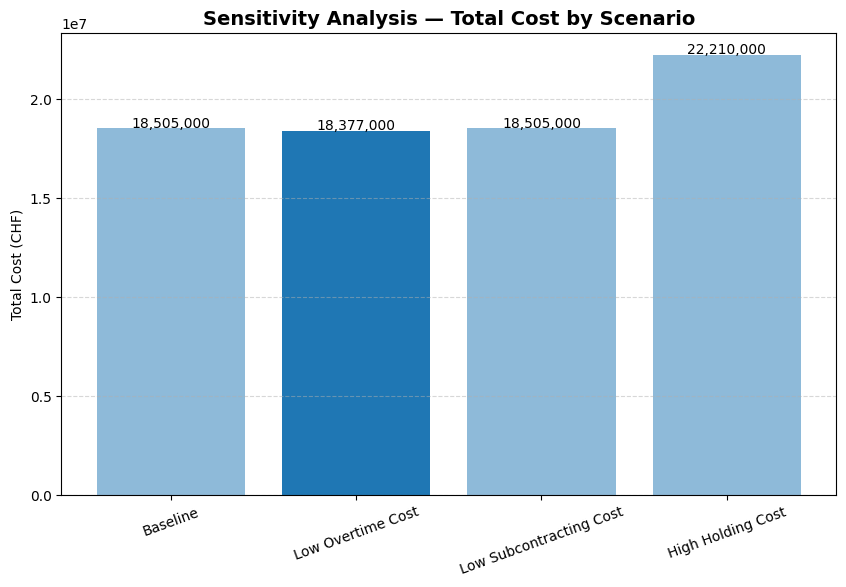

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    sensitivity_results["Scenario"],
    sensitivity_results["Total Cost"]
)

# Highlight best (min cost)
min_cost = sensitivity_results["Total Cost"].min()

for i, cost in enumerate(sensitivity_results["Total Cost"]):
    if cost == min_cost:
        bars[i].set_alpha(1)
    else:
        bars[i].set_alpha(0.5)

# Labels on top
for i, v in enumerate(sensitivity_results["Total Cost"]):
    plt.text(i, v + 50000, f"{int(v):,}", ha='center', fontsize=10)

plt.title("Sensitivity Analysis — Total Cost by Scenario", fontsize=14, fontweight="bold")
plt.ylabel("Total Cost (CHF)")
plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

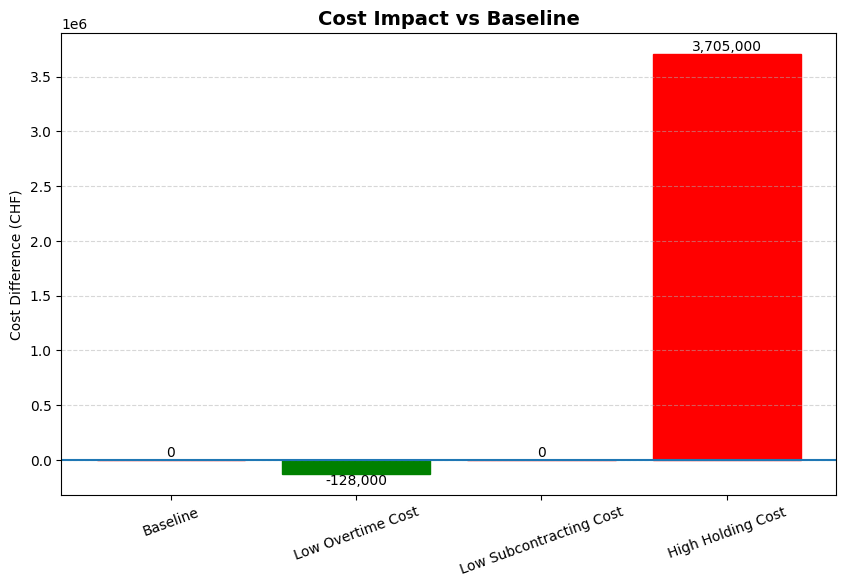

In [46]:
baseline = sensitivity_results["Total Cost"][0]

impact = sensitivity_results.copy()
impact["Delta vs Baseline"] = impact["Total Cost"] - baseline

plt.figure(figsize=(10,6))

bars = plt.bar(
    impact["Scenario"],
    impact["Delta vs Baseline"]
)

# Colors: green = better, red = worse
for i, val in enumerate(impact["Delta vs Baseline"]):
    if val < 0:
        bars[i].set_color("green")
    else:
        bars[i].set_color("red")

# Labels
for i, v in enumerate(impact["Delta vs Baseline"]):
    plt.text(i, v, f"{int(v):,}", ha='center', va='bottom' if v>=0 else 'top')

plt.axhline(0)

plt.title("Cost Impact vs Baseline", fontsize=14, fontweight="bold")
plt.ylabel("Cost Difference (CHF)")
plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# 7.1 Sensitivity Analysis
The sensitivity analysis highlights how the optimal production plan reacts to changes in key cost parameters.

First, reducing the overtime cost leads to a noticeable decrease in total cost. This indicates that the model starts using overtime to handle demand peaks instead of relying solely on hiring and firing. Overtime therefore appears as an effective short-term flexibility lever that allows the firm to adjust production without significantly modifying the workforce.

In contrast, reducing subcontracting cost does not affect the optimal solution. The total cost remains unchanged, and subcontracting is not used. This suggests that, even at lower costs, subcontracting remains less attractive than internal production. Possible explanations include capacity sufficiency of internal resources or the relative cost structure still favoring in-house production.

When increasing inventory holding cost, the total cost increases significantly. This shows that inventory plays a central role in the base strategy. As holding inventory becomes more expensive, the model is penalized, highlighting the trade-off between producing in advance and relying on more flexible but potentially costly alternatives.

Overall, the results demonstrate that the production strategy is highly sensitive to cost parameters. While overtime emerges as a relevant flexibility mechanism when its cost decreases, subcontracting does not appear to be a viable option under the tested conditions. This confirms that internal production and workforce adjustments remain the dominant strategy in this context.

# II. Inventory Management



In [81]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Demand_data (1).csv")
df.head()

Saving Demand_data (1).csv to Demand_data (1) (5).csv


,Day,3235 Movement (units),Oystersteel Case (units),Sapphire Crystal (units),Jubilee Bracelet (units),Lubricant Oil (grams),Diamond Marker (units),Gold Crown (units)
0,1,15,12,13,8,147,46,6
1,2,11,14,9,8,106,49,4
2,3,16,10,12,9,154,48,8
3,4,12,7,8,10,80,48,7
4,5,16,6,14,8,176,44,4


In [82]:
data = df.drop(columns=["Day"])

demand_stats = pd.DataFrame({
    "Component": data.columns,
    "Mean_Demand": data.mean().values,
    "Std_Demand": data.std().values
})

demand_stats["CV"] = demand_stats["Std_Demand"] / demand_stats["Mean_Demand"]

demand_stats

,Component,Mean_Demand,Std_Demand,CV
0,3235 Movement (units),14.260274,3.561190,0.249728
1,Oystersteel Case (units),15.178082,4.281132,0.282060
2,Sapphire Crystal (units),14.210959,3.587507,0.252447
3,Jubilee Bracelet (units),8.016438,0.994354,0.124039
4,Lubricant Oil (grams),150.723288,41.180021,0.273216
5,Diamond Marker (units),47.805479,5.093950,0.106556
6,Gold Crown (units),8.005479,3.032783,0.378838


In [83]:
def classify_demand(cv):
    if cv < 0.3:
        return "Stable"
    elif cv < 0.7:
        return "Moderate"
    else:
        return "Erratic"

demand_stats["Demand_Type"] = demand_stats["CV"].apply(classify_demand)

demand_stats

,Component,Mean_Demand,Std_Demand,CV,Demand_Type
0,3235 Movement (units),14.260274,3.561190,0.249728,Stable
1,Oystersteel Case (units),15.178082,4.281132,0.282060,Stable
2,Sapphire Crystal (units),14.210959,3.587507,0.252447,Stable
3,Jubilee Bracelet (units),8.016438,0.994354,0.124039,Stable
4,Lubricant Oil (grams),150.723288,41.180021,0.273216,Stable
5,Diamond Marker (units),47.805479,5.093950,0.106556,Stable
6,Gold Crown (units),8.005479,3.032783,0.378838,Moderate


In [84]:
components_data = pd.DataFrame({
    "Component": [
        "3235 Movement (units)",
        "Oystersteel Case (units)",
        "Sapphire Crystal (units)",
        "Jubilee Bracelet (units)",
        "Lubricant Oil (grams)",
        "Diamond Marker (units)",
        "Gold Crown (units)"
    ],
    "Lead_Time": [60, 45, 30, 35, 14, 21, 40],
    "Holding_Cost": [1200, 400, 200, 220, 50, 900, 350],
    "Ordering_Cost": [9000, 7000, 4000, 3500, 1000, 6000, 5000],
    "Shelf_Life": [365, 505, 365, 1460, 730, 1825, 730]
})

components_data

,Component,Lead_Time,Holding_Cost,Ordering_Cost,Shelf_Life
0,3235 Movement (units),60,1200,9000,365
1,Oystersteel Case (units),45,400,7000,505
2,Sapphire Crystal (units),30,200,4000,365
3,Jubilee Bracelet (units),35,220,3500,1460
4,Lubricant Oil (grams),14,50,1000,730
5,Diamond Marker (units),21,900,6000,1825
6,Gold Crown (units),40,350,5000,730


In [85]:
inventory = demand_stats.merge(components_data, on="Component", how="inner")
inventory

,Component,Mean_Demand,Std_Demand,CV,Demand_Type,Lead_Time,Holding_Cost,Ordering_Cost,Shelf_Life
0,3235 Movement (units),14.260274,3.561190,0.249728,Stable,60,1200,9000,365
1,Oystersteel Case (units),15.178082,4.281132,0.282060,Stable,45,400,7000,505
2,Sapphire Crystal (units),14.210959,3.587507,0.252447,Stable,30,200,4000,365
3,Jubilee Bracelet (units),8.016438,0.994354,0.124039,Stable,35,220,3500,1460
4,Lubricant Oil (grams),150.723288,41.180021,0.273216,Stable,14,50,1000,730
5,Diamond Marker (units),47.805479,5.093950,0.106556,Stable,21,900,6000,1825
6,Gold Crown (units),8.005479,3.032783,0.378838,Moderate,40,350,5000,730


In [88]:
# Calcul EOQ + ROP
inventory["Annual_Demand"] = inventory["Mean_Demand"] * 365

inventory["EOQ"] = np.sqrt(
    (2 * inventory["Annual_Demand"] * inventory["Ordering_Cost"]) /
    (inventory["Holding_Cost"] * 12)
)

inventory["ROP"] = inventory["Mean_Demand"] * inventory["Lead_Time"]

inventory

,Component,Mean_Demand,Std_Demand,CV,Demand_Type,Lead_Time,Holding_Cost,Ordering_Cost,Shelf_Life,Annual_Demand,EOQ,ROP,Safety_Stock,ROP_with_SS
0,3235 Movement (units),14.260274,3.561190,0.249728,Stable,60,1200,9000,365,5205.0,80.661329,855.616438,45.515012,901.131451
1,Oystersteel Case (units),15.178082,4.281132,0.282060,Stable,45,400,7000,505,5540.0,127.115433,683.013699,47.385864,730.399562
2,Sapphire Crystal (units),14.210959,3.587507,0.252447,Stable,30,200,4000,365,5187.0,131.491445,426.328767,32.421819,458.750586
3,Jubilee Bracelet (units),8.016438,0.994354,0.124039,Stable,35,220,3500,1460,2926.0,88.081402,280.575342,9.706419,290.281761
4,Lubricant Oil (grams),150.723288,41.180021,0.273216,Stable,14,50,1000,730,55014.0,428.228911,2110.126027,254.234522,2364.360549
5,Diamond Marker (units),47.805479,5.093950,0.106556,Stable,21,900,6000,1825,17449.0,139.240001,1003.915068,38.516625,1042.431694
6,Gold Crown (units),8.005479,3.032783,0.378838,Moderate,40,350,5000,730,2922.0,83.409489,320.219178,31.648655,351.867833


In [89]:
# Safety stock
z = 1.65

inventory["Safety_Stock"] = (
    z * inventory["Std_Demand"] * np.sqrt(inventory["Lead_Time"])
)

inventory["ROP_with_SS"] = inventory["ROP"] + inventory["Safety_Stock"]

inventory

,Component,Mean_Demand,Std_Demand,CV,Demand_Type,Lead_Time,Holding_Cost,Ordering_Cost,Shelf_Life,Annual_Demand,EOQ,ROP,Safety_Stock,ROP_with_SS
0,3235 Movement (units),14.260274,3.561190,0.249728,Stable,60,1200,9000,365,5205.0,80.661329,855.616438,45.515012,901.131451
1,Oystersteel Case (units),15.178082,4.281132,0.282060,Stable,45,400,7000,505,5540.0,127.115433,683.013699,47.385864,730.399562
2,Sapphire Crystal (units),14.210959,3.587507,0.252447,Stable,30,200,4000,365,5187.0,131.491445,426.328767,32.421819,458.750586
3,Jubilee Bracelet (units),8.016438,0.994354,0.124039,Stable,35,220,3500,1460,2926.0,88.081402,280.575342,9.706419,290.281761
4,Lubricant Oil (grams),150.723288,41.180021,0.273216,Stable,14,50,1000,730,55014.0,428.228911,2110.126027,254.234522,2364.360549
5,Diamond Marker (units),47.805479,5.093950,0.106556,Stable,21,900,6000,1825,17449.0,139.240001,1003.915068,38.516625,1042.431694
6,Gold Crown (units),8.005479,3.032783,0.378838,Moderate,40,350,5000,730,2922.0,83.409489,320.219178,31.648655,351.867833


In [90]:
#stock politic
def choose_policy(row):
    if row["Demand_Type"] == "Stable":
        return "EOQ + Reorder Point"
    else:
        return "Reorder Point + Safety Stock"

inventory["Policy"] = inventory.apply(choose_policy, axis=1)

inventory[[
    "Component",
    "Demand_Type",
    "Policy",
    "EOQ",
    "ROP",
    "Safety_Stock",
    "ROP_with_SS"
]]

,Component,Demand_Type,Policy,EOQ,ROP,Safety_Stock,ROP_with_SS
0,3235 Movement (units),Stable,EOQ + Reorder Point,80.661329,855.616438,45.515012,901.131451
1,Oystersteel Case (units),Stable,EOQ + Reorder Point,127.115433,683.013699,47.385864,730.399562
2,Sapphire Crystal (units),Stable,EOQ + Reorder Point,131.491445,426.328767,32.421819,458.750586
3,Jubilee Bracelet (units),Stable,EOQ + Reorder Point,88.081402,280.575342,9.706419,290.281761
4,Lubricant Oil (grams),Stable,EOQ + Reorder Point,428.228911,2110.126027,254.234522,2364.360549
5,Diamond Marker (units),Stable,EOQ + Reorder Point,139.240001,1003.915068,38.516625,1042.431694
6,Gold Crown (units),Moderate,Reorder Point + Safety Stock,83.409489,320.219178,31.648655,351.867833


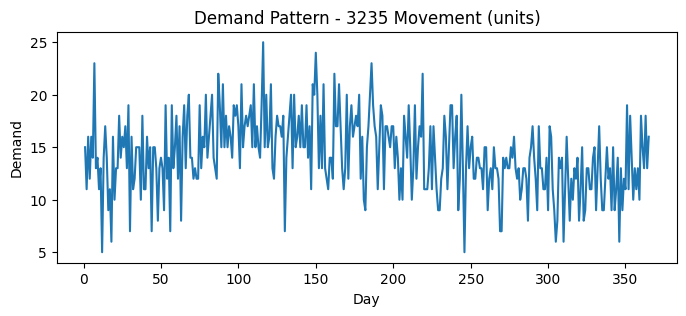

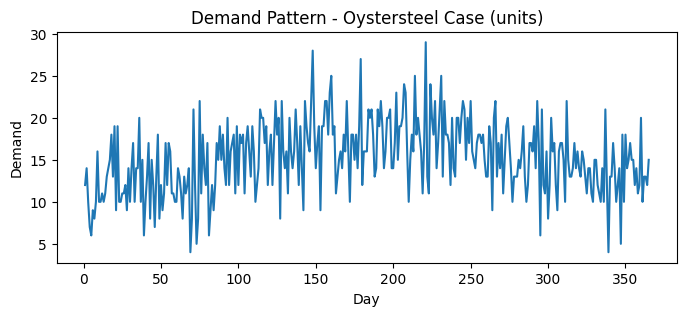

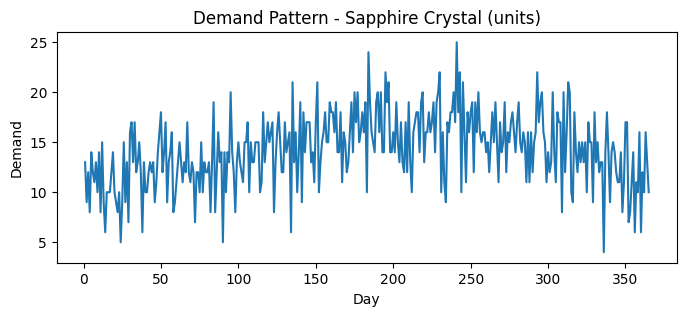

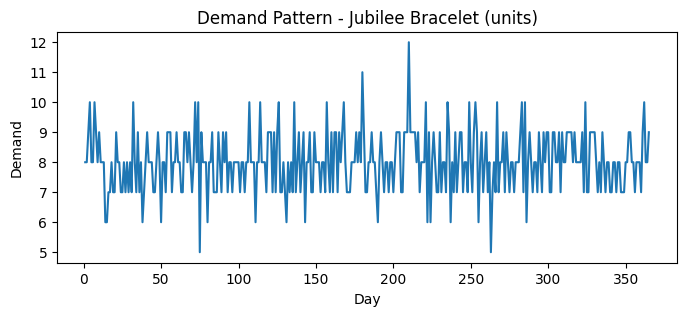

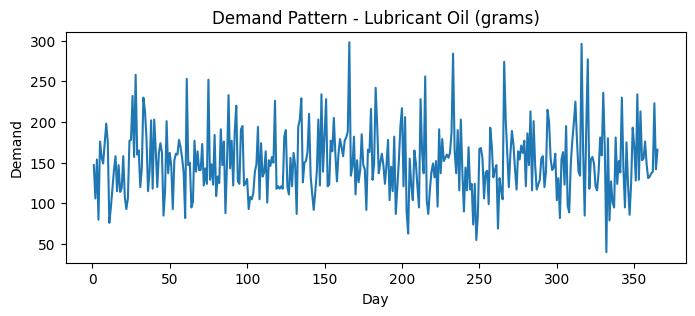

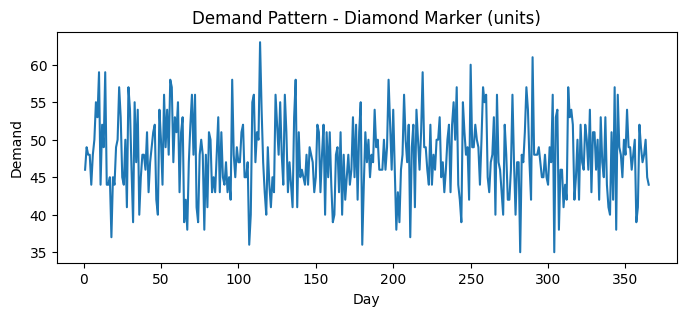

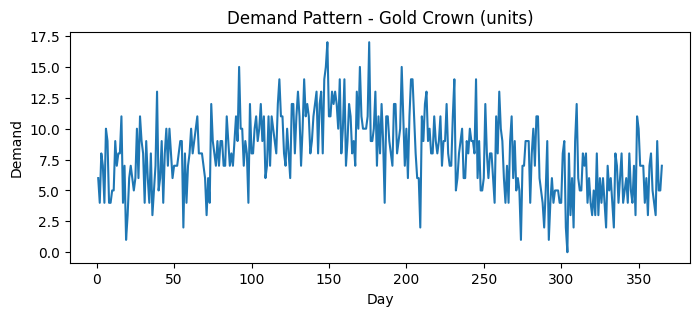

In [91]:
for col in data.columns:
    plt.figure(figsize=(8,3))
    plt.plot(df["Day"], df[col])
    plt.title(f"Demand Pattern - {col}")
    plt.xlabel("Day")
    plt.ylabel("Demand")
    plt.show()

# Sensitivity Analysis: Strategy Robustness

In [92]:
# Sensitivity sur la demande
scenarios = [0.7, 0.9, 1.1, 1.3]

results = []

for factor in scenarios:

    temp = inventory.copy()

    temp["Adj_Annual_Demand"] = temp["Annual_Demand"] * factor

    temp["Adj_EOQ"] = np.sqrt(
        (2 * temp["Adj_Annual_Demand"] * temp["Ordering_Cost"]) /
        (temp["Holding_Cost"] * 12)
    )

    for _, row in temp.iterrows():
        results.append({
            "Component": row["Component"],
            "Demand_Factor": factor,
            "EOQ": row["Adj_EOQ"]
        })

sensitivity = pd.DataFrame(results)
sensitivity.head()

,Component,Demand_Factor,EOQ
0,3235 Movement (units),0.7,67.486110
1,Oystersteel Case (units),0.7,106.352402
2,Sapphire Crystal (units),0.7,110.013636
3,Jubilee Bracelet (units),0.7,73.694188
4,Lubricant Oil (grams),0.7,358.282012


In [94]:
scenarios = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]

results = []

z = 1.65  # service level 95%

for factor in scenarios:
    temp = inventory.copy()

    # Adjust demand
    temp["Adj_Mean_Demand"] = temp["Mean_Demand"] * factor
    temp["Adj_Std_Demand"] = temp["Std_Demand"] * factor
    temp["Adj_Annual_Demand"] = temp["Annual_Demand"] * factor

    # EOQ
    temp["Adj_EOQ"] = np.sqrt(
        (2 * temp["Adj_Annual_Demand"] * temp["Ordering_Cost"]) /
        (temp["Holding_Cost"] * 12)
    )

    # Reorder point
    temp["Adj_ROP"] = temp["Adj_Mean_Demand"] * temp["Lead_Time"]

    # Safety stock
    temp["Adj_Safety_Stock"] = (
        z * temp["Adj_Std_Demand"] * np.sqrt(temp["Lead_Time"])
    )

    temp["Adj_ROP_with_SS"] = temp["Adj_ROP"] + temp["Adj_Safety_Stock"]

    # Average cycle stock
    temp["Cycle_Stock"] = temp["Adj_EOQ"] / 2

    # Average total stock
    temp["Avg_Stock_Level"] = temp["Cycle_Stock"] + temp["Adj_Safety_Stock"]

    # Number of orders per year
    temp["Orders_Per_Year"] = temp["Adj_Annual_Demand"] / temp["Adj_EOQ"]

    # Total annual ordering cost
    temp["Annual_Ordering_Cost"] = (
        temp["Orders_Per_Year"] * temp["Ordering_Cost"]
    )

    # Total annual holding cost
    temp["Annual_Holding_Cost_Total"] = (
        temp["Avg_Stock_Level"] * temp["Holding_Cost"] * 12
    )

    # Total annual inventory cost
    temp["Total_Inventory_Cost"] = (
        temp["Annual_Ordering_Cost"] + temp["Annual_Holding_Cost_Total"]
    )

    for _, row in temp.iterrows():
        results.append({
            "Component": row["Component"],
            "Demand_Factor": factor,
            "EOQ": row["Adj_EOQ"],
            "ROP": row["Adj_ROP"],
            "Safety_Stock": row["Adj_Safety_Stock"],
            "Avg_Stock_Level": row["Avg_Stock_Level"],
            "Orders_Per_Year": row["Orders_Per_Year"],
            "Total_Inventory_Cost": row["Total_Inventory_Cost"]
        })

sensitivity_full = pd.DataFrame(results)
sensitivity_full.head()

,Component,Demand_Factor,EOQ,ROP,Safety_Stock,Avg_Stock_Level,Orders_Per_Year,Total_Inventory_Cost
0,3235 Movement (units),0.7,67.486110,598.931507,31.860509,65.603564,53.988888,1.430591e+06
1,Oystersteel Case (units),0.7,106.352402,478.109589,33.170105,86.346306,36.463681,6.697080e+05
2,Sapphire Crystal (units),0.7,110.013636,298.430137,22.695273,77.702091,33.004091,3.185014e+05
3,Jubilee Bracelet (units),0.7,73.694188,196.402740,6.794493,43.641587,27.793237,2.124901e+05
4,Lubricant Oil (grams),0.7,358.282012,1477.088219,177.964165,357.105171,107.484604,3.217477e+05


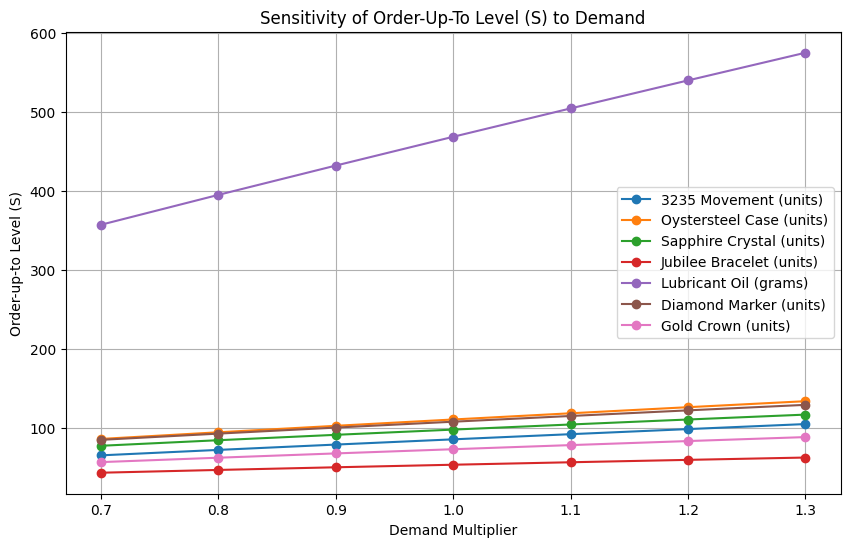

In [101]:
plt.figure(figsize=(10,6))

for comp in sensitivity_full["Component"].unique():
    subset = sensitivity_full[sensitivity_full["Component"] == comp]

    plt.plot(
        subset["Demand_Factor"],
        subset["Avg_Stock_Level"],  # ou EOQ ou ROP_with_SS
        marker="o",
        label=comp
    )

plt.title("Sensitivity of Order-Up-To Level (S) to Demand")
plt.xlabel("Demand Multiplier")
plt.ylabel("Order-up-to Level (S)")

plt.legend()
plt.grid()

plt.show()

The graph shows that the order-up-to level (S) increases steadily with demand for all components.

This indicates that higher demand requires higher inventory levels to ensure product availability during lead time. The relationship appears linear, suggesting that the inventory model reacts proportionally to demand changes.

Differences between components are also visible: some items, such as lubricant oil, require significantly higher stock levels due to their higher demand or variability, while others remain relatively low.

Overall, the results confirm that the inventory policy is responsive and scalable, adapting efficiently to changes in demand across all components.

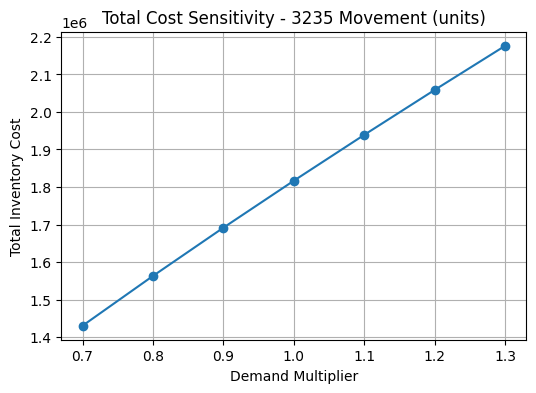

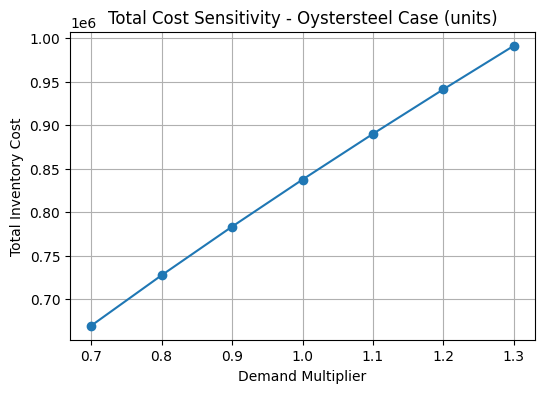

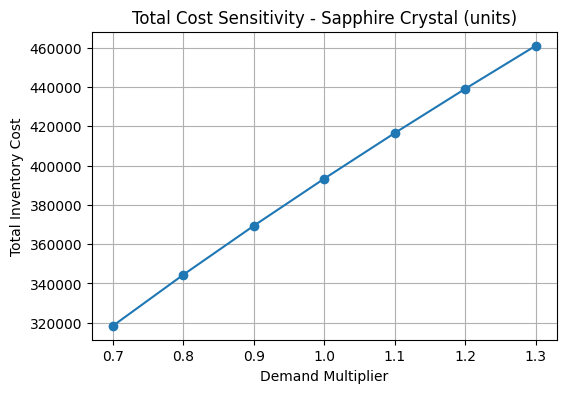

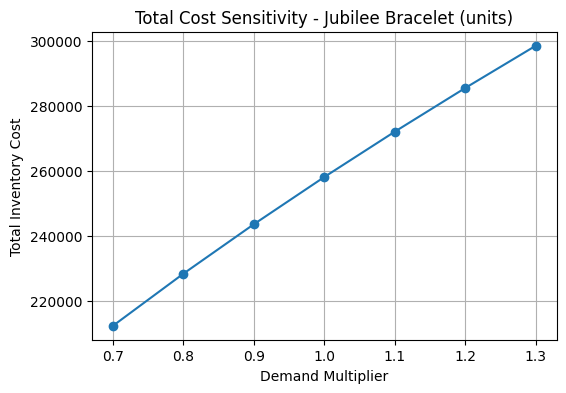

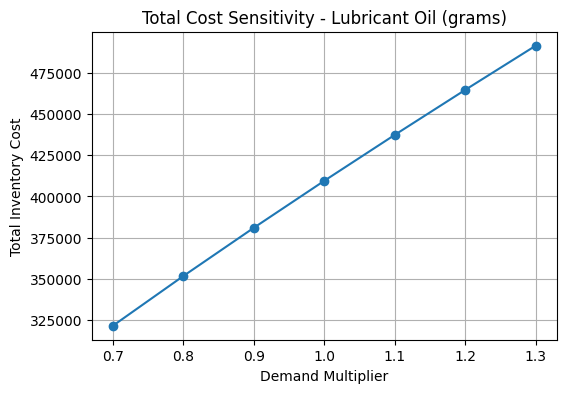

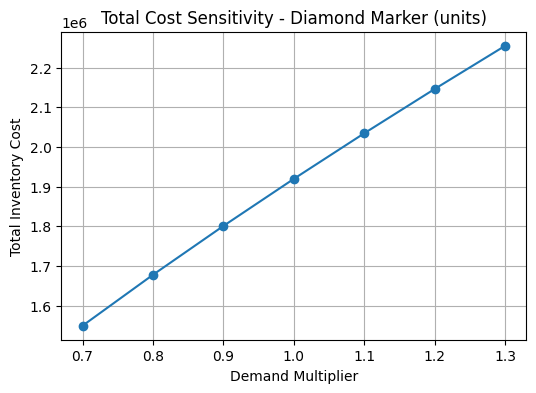

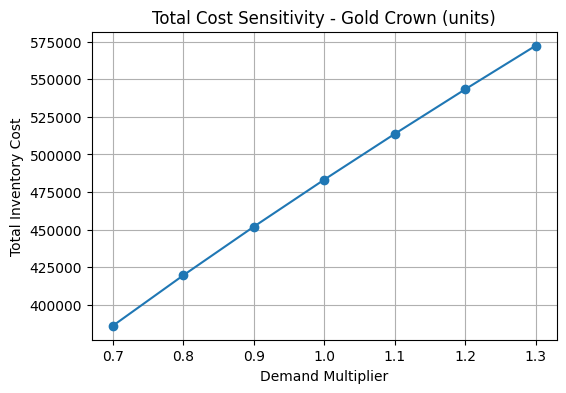

In [97]:
for comp in sensitivity_full["Component"].unique():
    subset = sensitivity_full[sensitivity_full["Component"] == comp]

    plt.figure(figsize=(6,4))
    plt.plot(subset["Demand_Factor"], subset["Total_Inventory_Cost"], marker="o")
    plt.title(f"Total Cost Sensitivity - {comp}")
    plt.xlabel("Demand Multiplier")
    plt.ylabel("Total Inventory Cost")
    plt.grid()
    plt.show()

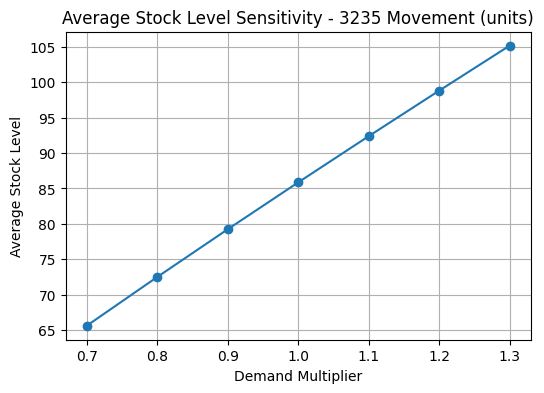

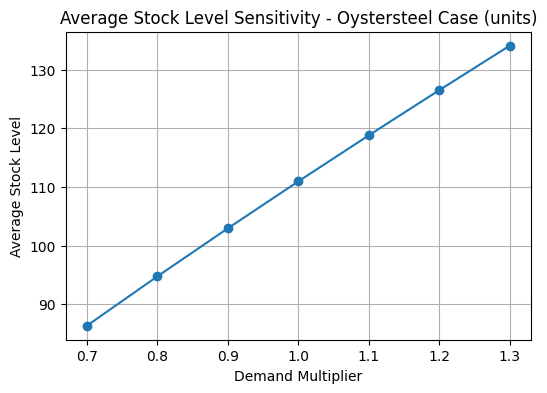

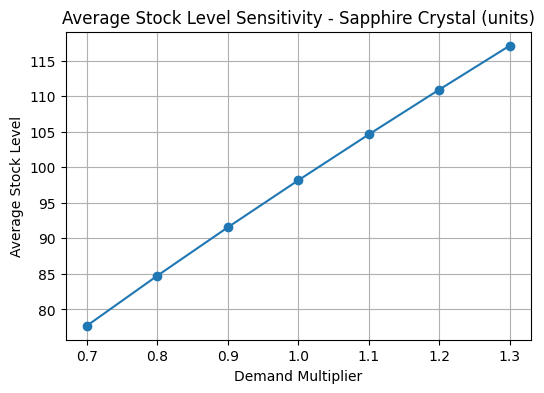

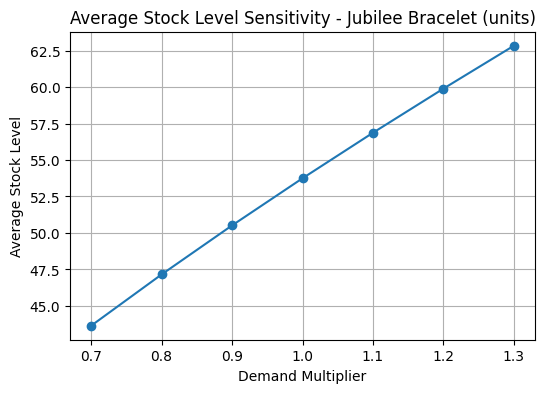

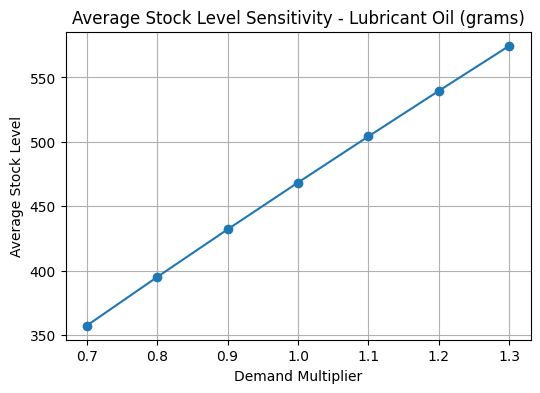

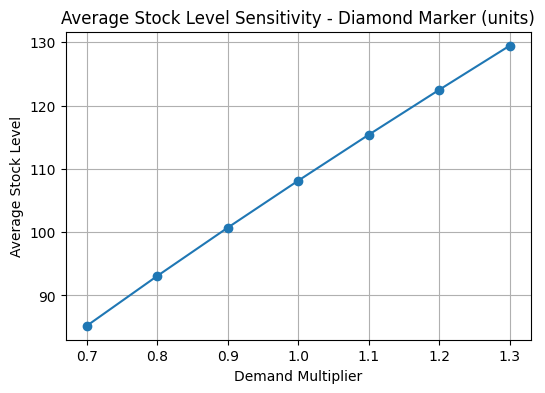

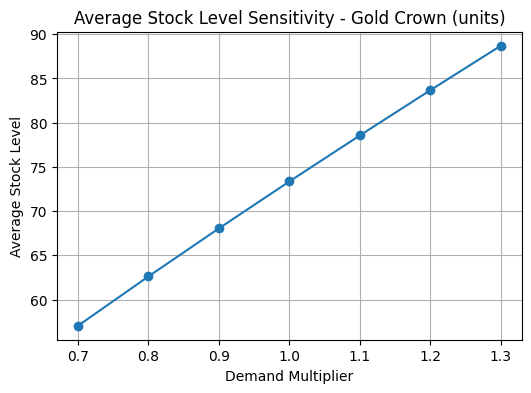

In [96]:
for comp in sensitivity_full["Component"].unique():
    subset = sensitivity_full[sensitivity_full["Component"] == comp]

    plt.figure(figsize=(6,4))
    plt.plot(subset["Demand_Factor"], subset["Avg_Stock_Level"], marker="o")
    plt.title(f"Average Stock Level Sensitivity - {comp}")
    plt.xlabel("Demand Multiplier")
    plt.ylabel("Average Stock Level")
    plt.grid()
    plt.show()

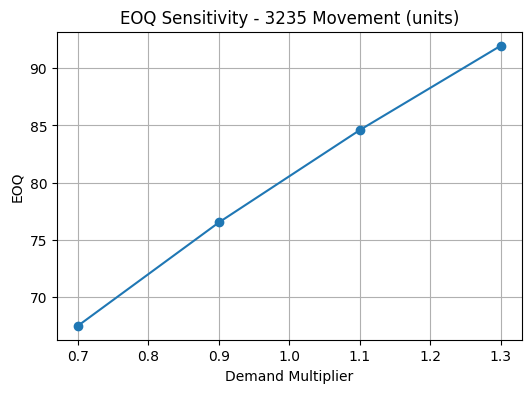

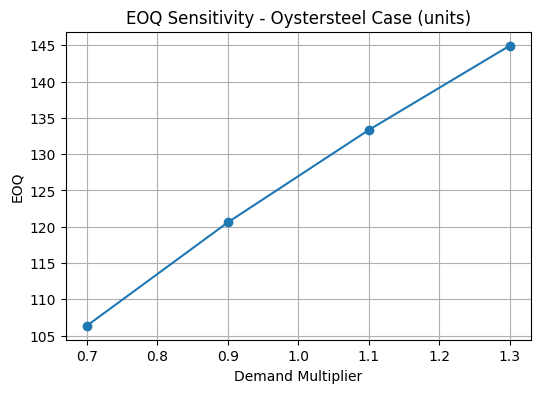

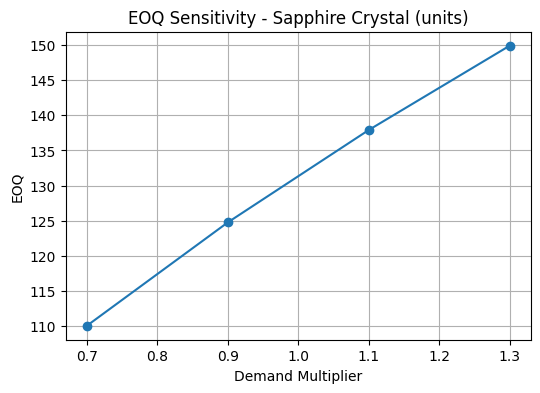

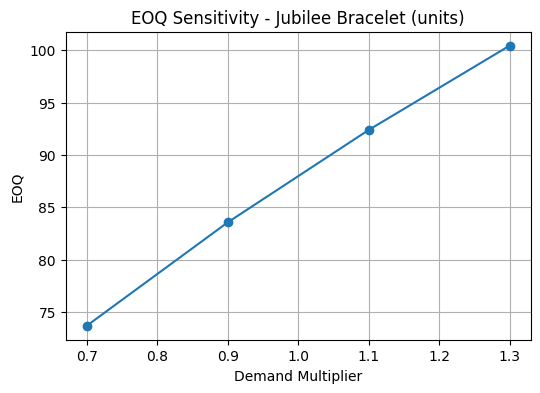

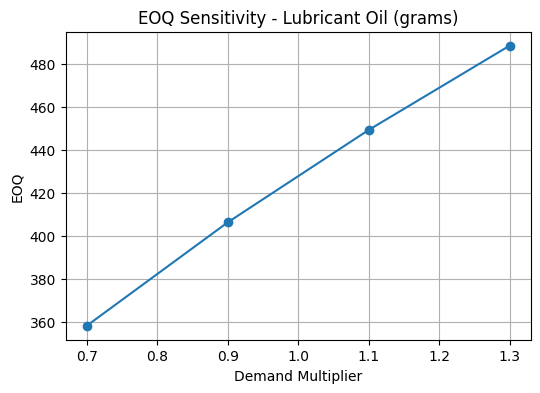

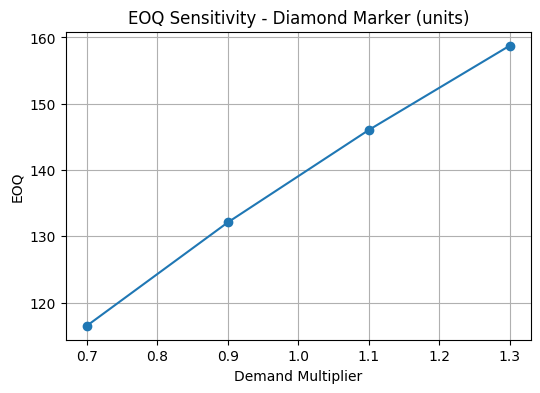

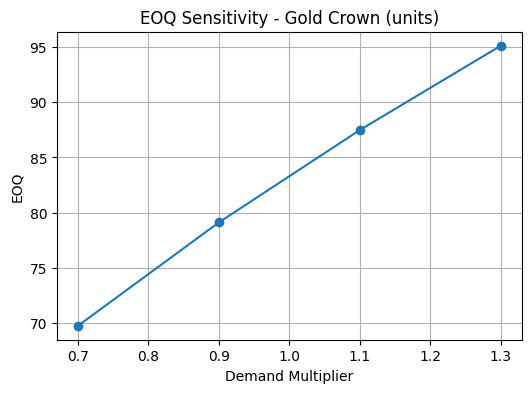

In [93]:
for comp in sensitivity["Component"].unique():

    subset = sensitivity[sensitivity["Component"] == comp]

    plt.figure(figsize=(6,4))
    plt.plot(subset["Demand_Factor"], subset["EOQ"], marker="o")

    plt.title(f"EOQ Sensitivity - {comp}")
    plt.xlabel("Demand Multiplier")
    plt.ylabel("EOQ")

    plt.grid()
    plt.show()

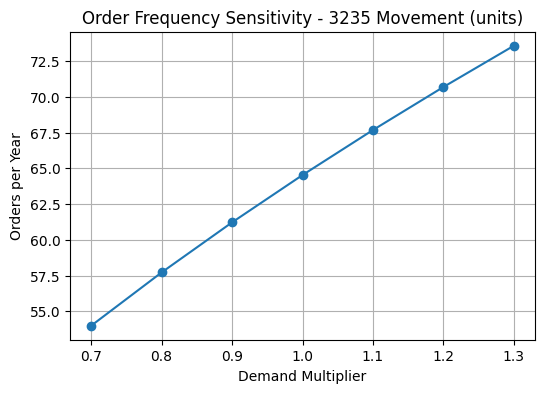

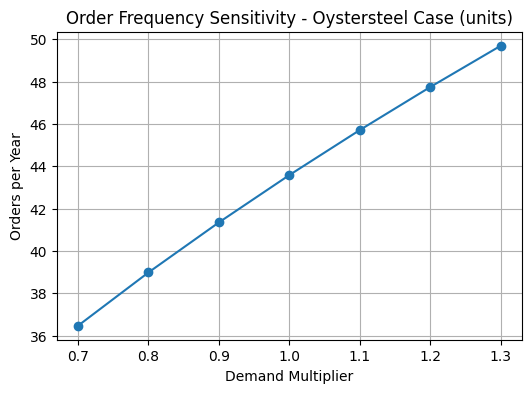

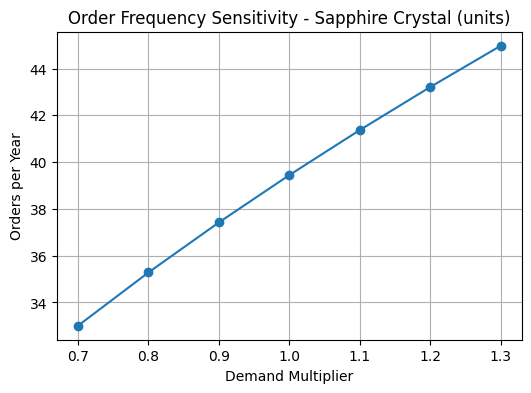

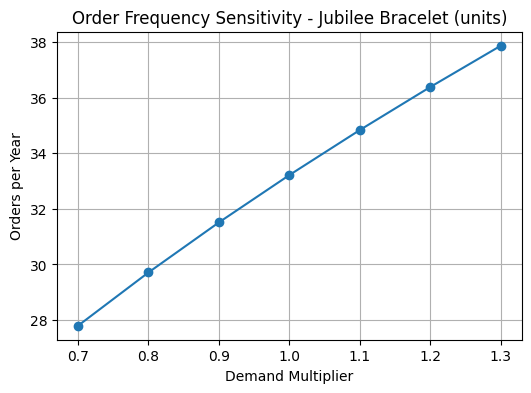

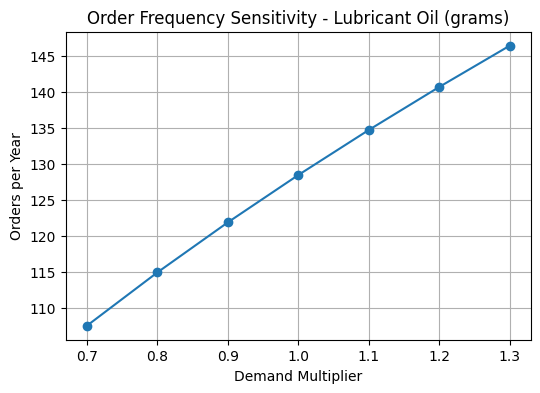

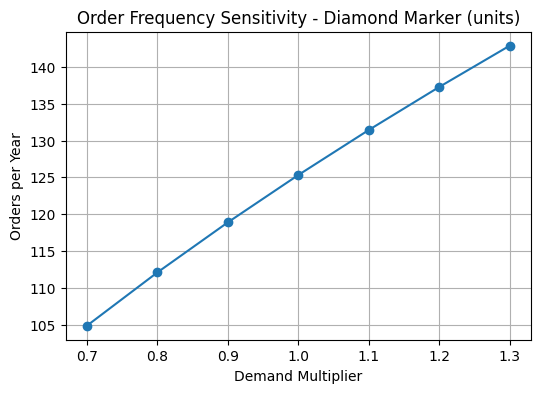

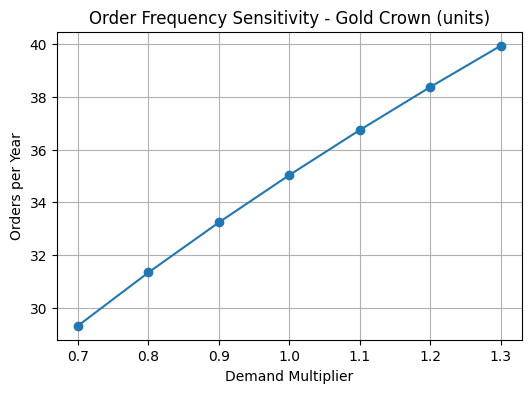

In [98]:
for comp in sensitivity_full["Component"].unique():
    subset = sensitivity_full[sensitivity_full["Component"] == comp]

    plt.figure(figsize=(6,4))
    plt.plot(subset["Demand_Factor"], subset["Orders_Per_Year"], marker="o")
    plt.title(f"Order Frequency Sensitivity - {comp}")
    plt.xlabel("Demand Multiplier")
    plt.ylabel("Orders per Year")
    plt.grid()
    plt.show()

In [99]:
summary_sensitivity = sensitivity_full.groupby("Demand_Factor")[[
    "EOQ", "Avg_Stock_Level", "Orders_Per_Year", "Total_Inventory_Cost"
]].mean().reset_index()

summary_sensitivity.round(2)

,Demand_Factor,EOQ,Avg_Stock_Level,Orders_Per_Year,Total_Inventory_Cost
0,0.7,128.87,110.38,56.13,698361.79
1,0.8,137.77,121.39,60.00,759037.81
2,0.9,146.13,132.13,63.64,817491.41
3,1.0,154.03,142.65,67.08,874084.43
4,1.1,161.55,152.97,70.36,929090.04
5,1.2,168.73,163.13,73.49,982720.46
6,1.3,175.62,173.13,76.49,1035144.44


The sensitivity analysis shows that the Economic Order Quantity (EOQ) decreases when demand is reduced.

This is consistent with inventory theory, as lower demand requires smaller order quantities to balance ordering and holding costs efficiently.

Across all components, EOQ adapts proportionally to demand changes, indicating that the inventory model is responsive and robust.

This confirms that the selected inventory policy remains valid under varying demand conditions, although accurate demand forecasting remains critical for optimal performance.

# Conclusion
The analysis of Aurelius SA’s inventory system reveals that most components exhibit stable demand patterns, with relatively low variability over time.

This allows the use of classical deterministic inventory models such as the Economic Order Quantity (EOQ) combined with a reorder point (ROP). These models enable the company to balance ordering and holding costs efficiently while ensuring product availability.

For components with slightly higher variability, the addition of safety stock provides protection against demand uncertainty and lead time fluctuations. This ensures a high service level and reduces the risk of stockouts.

Overall, the inventory system appears well suited to structured and predictable demand conditions, allowing for cost-efficient and reliable operations.

The sensitivity analysis demonstrates that the optimal order quantities are highly dependent on demand levels.

As demand increases, EOQ also increases, reflecting the need for larger and less frequent orders. Conversely, when demand decreases, smaller order quantities become optimal.

This confirms that the inventory model is responsive and robust across different demand scenarios. However, it also highlights the importance of accurate demand forecasting, as even moderate changes in demand significantly impact ordering decisions.

From a managerial perspective, the results suggest that Aurelius SA should prioritize simple and well-structured inventory policies for most components, as demand remains relatively stable.

The company should implement EOQ-based ordering combined with reorder points to optimize costs while maintaining service levels. For components with higher variability or longer lead times, safety stock should be introduced to mitigate the risk of stockouts.

The analysis also shows that not all components require the same level of attention. High-cost or high-demand items should be monitored more closely, while more stable and less critical components can be managed with standardized policies.

Finally, the sensitivity analysis highlights the importance of demand forecasting. Improving forecast accuracy would allow Aurelius SA to further optimize its inventory decisions and reduce unnecessary costs.